In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
from scipy.stats import crystalball
import scipy.special as sc

In [3]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2080<= dataframe3.iloc[i,9][1]< 2120):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [5]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32411/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32411/905049170.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32411/905049170.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [89]:
def Tail_Func(x, mu, sigma, c,b, f):
    z = np.sqrt(b**2/(2*sigma**2))*(sigma**2/b**2-(x-c)/b)
    guassian = (np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2)
    
    tail = np.sqrt(np.exp(sigma**2/b**2)/(4*b**2))*np.exp(-(x-c)/b)*special.erfc(z)
    
    return (1-f)*guassian+f*tail

def NegLogLTail(params,data):
    x = Tail_Func(data,*params)
    x = x[x > 0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLTail(data, initial_params):
    result = minimize(NegLogLTail, initial_params, args=(data),
                      method='L-BFGS-B', bounds=[(0, None), (0, None), (None, None), (None, None), (0,1)])
    return result.x

def Chi2(data, arr):
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num, range = [int(min(data)), int(max(data))])
    
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Tail_Func(filtered_bin_centers,*arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    fitted_pdf = Tail_Func(x_values, *arr)*len(data)*bin_width
    
    return x_values, fitted_pdf

def Residual_Plot(data, arr):
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = Tail_Func(filtered_bin_centers,*arr, min(data), max(data))*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

In [92]:
from iminuit import cost, Minuit

def Tail_Func(x, mu, sigma, c,b, f):
    z = np.sqrt(b**2/(2*sigma**2))*(sigma**2/b**2-(x-c)/b)
    guassian = (np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2)
    
    tail = np.sqrt(np.exp(sigma**2/b**2)/(4*b**2))*np.exp(-(x-c)/b)*special.erfc(z)
    return (1-f)*guassian+f*tail

data = np.asarray(NTD_2100)

c = cost.UnbinnedNLL(data, Tail_Func)

m = Minuit(c, mu=2104, sigma=2, c=1, b=1, f=0.1)
m.limits["f"] = (0, 1)
m.limits["mu"] = (0, None)
m.limits["sigma"] = (0, None)
m.migrad()

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32411/2838773860.py:7: RuntimeWarning: overflow encountered in exp
  tail = np.sqrt(np.exp(sigma**2/b**2)/(4*b**2))*np.exp(-(x-c)/b)*special.erfc(z)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32411/2838773860.py:7: RuntimeWarning: invalid value encountered in multiply
  tail = np.sqrt(np.exp(sigma**2/b**2)/(4*b**2))*np.exp(-(x-c)/b)*special.erfc(z)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.046e+04                  │              Nfcn = 542              │
│ EDM = 3.99e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │ 2.1027e3  │ 0.0000e3  │            │            │    0    │         │       │
│ 1 │ sigma │  7.6585   │  0.0000   │            │            │    0    │         │       │
│ 2 │ c     │ 9.9977e-1 │ 0.0000e-1 │            │            │         │         │       │
│ 3 │ b     │ 9.9886e-1 │ 0.0000e-1 │            │            │         │         │       │
│ 4 │ f     │     0     │     0     │            │            │    0    │    1    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

[2.10273722e+03 7.65854945e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00]


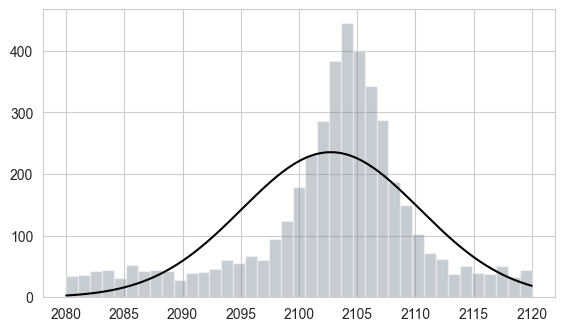

In [91]:
data = np.asarray(NTD_2100)
mu = 2104
c = 1
sigma = 2.20254997e+00
b = 1
f=0.1

initial_parms = [mu, sigma, c, b, f]
data_fits= MinimizeNegLogLTail(data, initial_parms)

x_values, fitted_pdf = Graph(data, data_fits)

chisq = Chi2(data, data_fits)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(chisq, decimals=2)) +'/' +str(int(max(data) - min(data)) - 4, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(data) - min(data)) - 4, chisq), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (data_fits[0], ),
    r'$\sigma=%.2f$' % (data_fits[1], ),
    r'$c=%.2f$' % (data_fits[2], ), 
    r'$b=%.2f$' % (data_fits[3], ), 
    ))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.hist(data, bins = int(max(data) - min(data)), color='slategray', alpha=0.4)
print(data_fits)

[2.2092e+03 2.0000e+00 1.0000e+00 1.0000e+00 5.0000e-01]


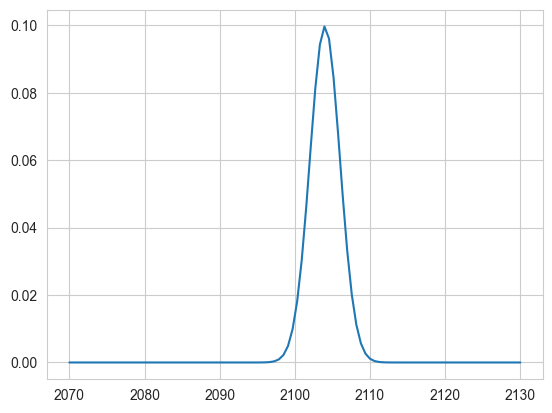

In [88]:
x = np.linspace(2070, 2130, 100)
plt.plot(x, Tail_Func(x,2104,2,1,1,0.5))

print(MinimizeNegLogLTail(x,[2104,2,1,1,0.5]))